# Laboratorio 1 — Series de Tiempo
## 3. Modelado y predicción (inciso 4.f–k y ejercicio 5)
**Universidad del Valle de Guatemala · Facultad de Ingeniería · Departamento de Ciencias de la Computación**
**CC3084 — Data Science · Semestre II 2026**

**Grupo:** Dulce Ambrosio · Daniel Chet · Javier Linares

**Carnt(s):** 231143 · 231177 · 231135

Este cuaderno continúa el trabajo de `01_limpieza_eda` (inciso 1) y `02_series_tiempo`
(incisos 2, 3 y el análisis preliminar 4.a–e de Total, Vía Aérea, Vía Terrestre y Tipo Turista).
Aquí se completa el análisis 4.a–e de las **cuatro series que faltaban** (Vía Marítima, Tipo
Excursionista, Tipo Viajero, Tipo Cruceristas) y se hace el **modelado completo (4.f–k)** de las
**ocho series** con ARIMA/SARIMA (manual y por búsqueda de AIC), Prophet, Holt-Winters,
suavizamiento exponencial simple y seasonal naive, cerrando con el **análisis comparativo
(ejercicio 5)** entre categorías.

In [ ]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
sys.path.append(str(ROOT / '02_series_tiempo' / 'src'))
sys.path.append(str(ROOT / '03_modelado_prediccion' / 'src'))
import config, series, modelado as mod

config.aplicar_estilo()
MILES = FuncFormatter(config.miles)
P = config.PALETTE

df = series.cargar_limpio()
print('Datos limpios:', len(df), 'registros,', df['fecha'].nunique(), 'meses')

Datos limpios: 161015 registros, 210 meses


In [ ]:
# Reconstrucción de las 8 series (idéntico a 02_analisis_preliminar_series.ipynb)
series_dict = {'Total': series.serie_mensual(df)}
for v in ['Aérea', 'Terrestre', 'Marítima']:
    series_dict[f'Vía: {v}'] = series.serie_mensual(df, 'Vía', v)
tipos = list(df['Tipo de Viajero'].value_counts().index)
for t in tipos:
    series_dict[f'Tipo: {t}'] = series.serie_mensual(df, 'Tipo de Viajero', t)
list(series_dict.keys())

['Total',
 'Vía: Aérea',
 'Vía: Terrestre',
 'Vía: Marítima',
 'Tipo: Turista',
 'Tipo: Viajero',
 'Tipo: Excursionista',
 'Tipo: Cruceristas']

## Parte A — Análisis preliminar de las series faltantes (inciso 4.a–e)

El cuaderno `02` ya cubrió a detalle Total mensual, Vía Aérea, Vía Terrestre y Tipo Turista.
Aquí completamos el mismo análisis (inicio/fin/frecuencia, gráfico, descomposición, ACF/PACF,
ADF/KPSS) para las cuatro series restantes: **Vía Marítima**, **Tipo Excursionista**,
**Tipo Viajero** y **Tipo Cruceristas**.

### Serie: Vía Marítima (inciso 4.a–e)

=== Vía Marítima ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-0.99  p=0.757  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-4.12  p=0.001  -> estacionaria (5%)
KPSS niveles     : stat=0.121  p=0.100  -> estacionaria (5%)


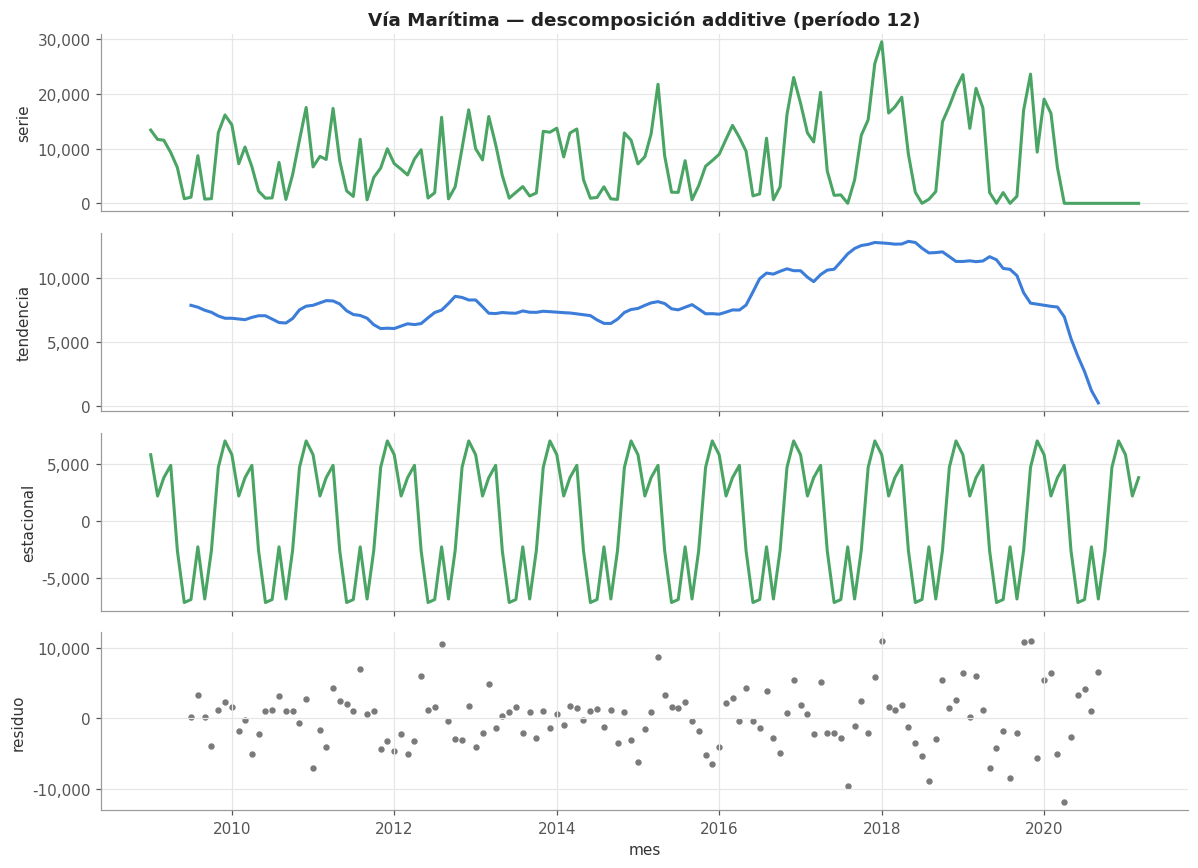

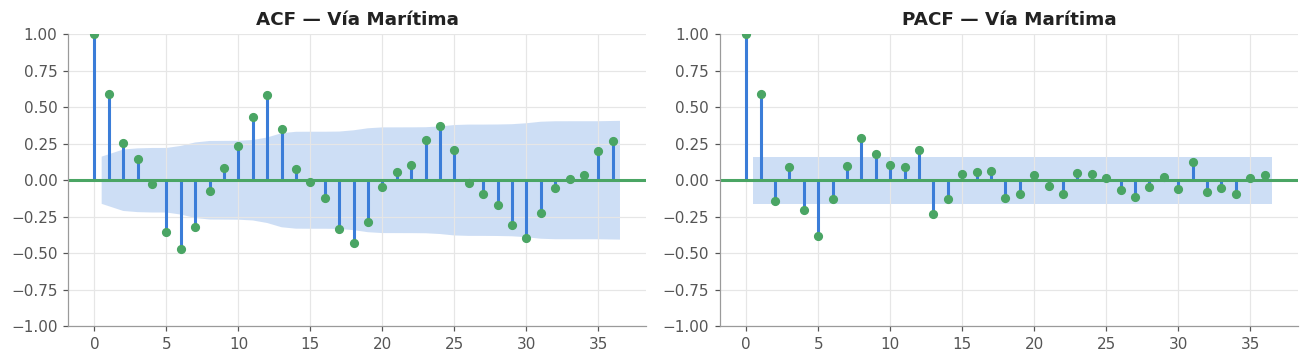

Fuerza de tendencia: 0.31  |  Fuerza estacional: 0.61


In [ ]:
a0, a1, k0 = series.analiza_serie('Vía Marítima', series_dict['Vía: Marítima'], 'via_maritima', P['verde'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Vía: Marítima'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Vía Marítima.**
Es la serie de menor volumen y la más irregular de las tres vías: varios meses de entrenamiento
en cero (barcos que no atracaron ese mes) y una media de apenas 7,991 viajeros mensuales,
muy por debajo de los ~90 mil de Aérea o ~140 mil de Terrestre. La fuerza estacional
(0.61) es, de hecho, la más alta de las tres vías, coherente con que los cruceros
siguen una temporada bastante marcada (noviembre–abril). La ADF en niveles no rechaza raíz
unitaria (p=0.76) pero sí lo hace tras una diferenciación (p=0.0009),
así que no es estacionaria en media y necesita d=1; por los ceros frecuentes la descomposición
se hace en modo aditivo, no multiplicativo.

### Serie: Tipo Excursionista (inciso 4.a–e)

=== Tipo Excursionista ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.13  p=0.232  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-4.72  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.504  p=0.041  -> NO estacionaria (5%)


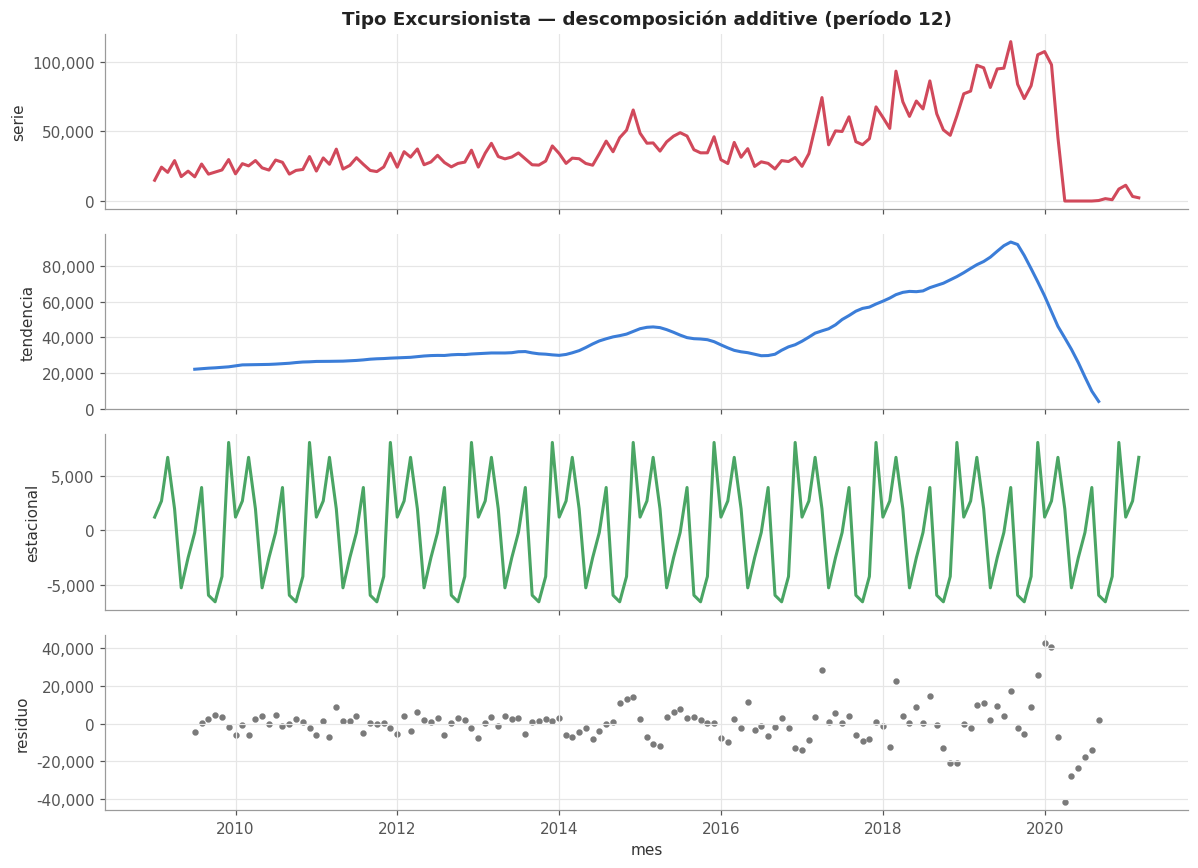

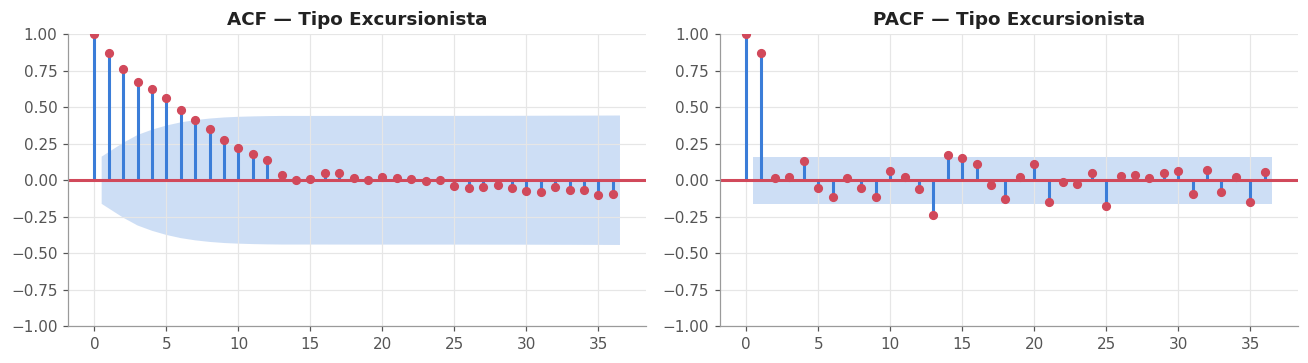

Fuerza de tendencia: 0.74  |  Fuerza estacional: 0.10


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Excursionista', series_dict['Tipo: Excursionista'], 'tipo_excursionista', P['rojo'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Excursionista'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Excursionista.**
Acompaña a Turista en tendencia (fuerza de tendencia 0.74) pero con una
estacionalidad mucho más débil (0.10) — tiene sentido, porque el excursionista
(que no pernocta) depende menos de vacaciones largas y más del tránsito fronterizo cotidiano.
La ADF en niveles no rechaza la raíz unitaria (p=0.23); tras d=1 sí lo hace
(p=0.00008). No estacionaria en media ni en varianza (conviene log).

### Serie: Tipo Viajero (inciso 4.a–e)

=== Tipo Viajero ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.13  p=0.232  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-5.24  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.847  p=0.010  -> NO estacionaria (5%)


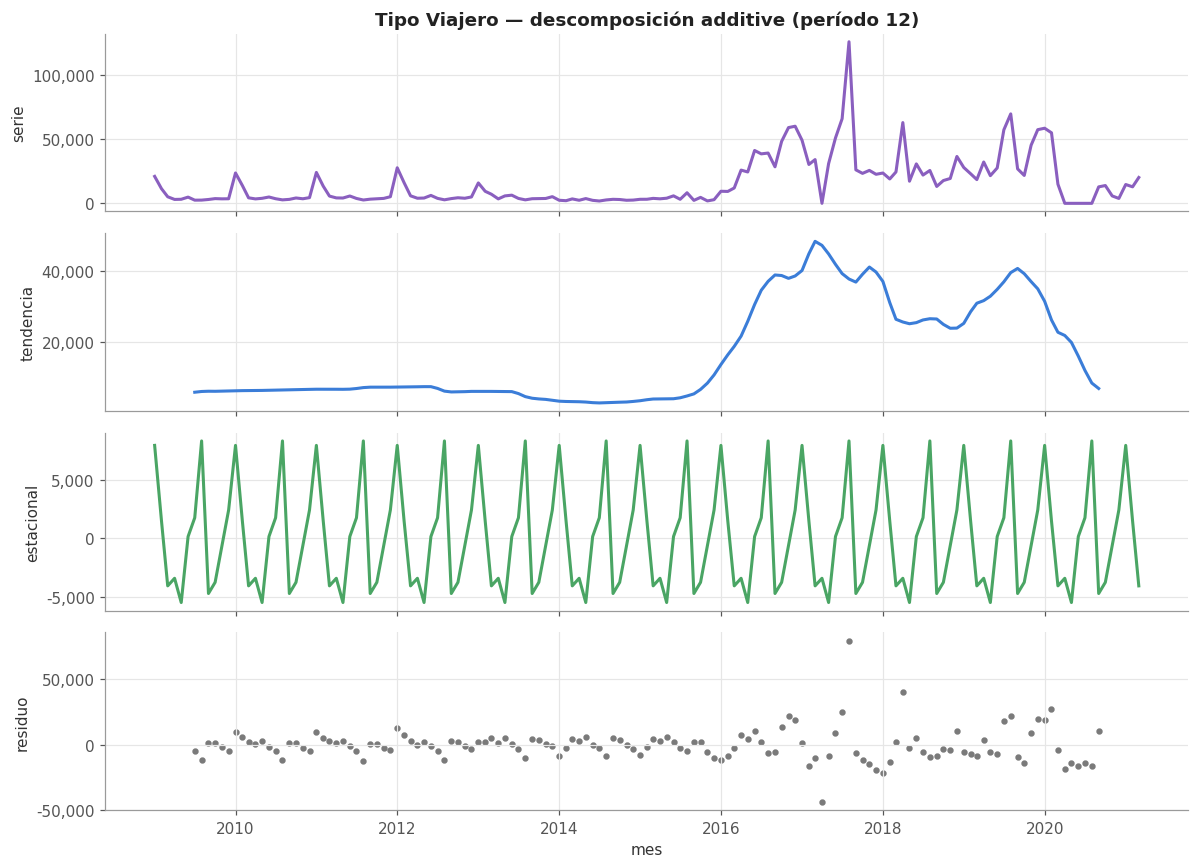

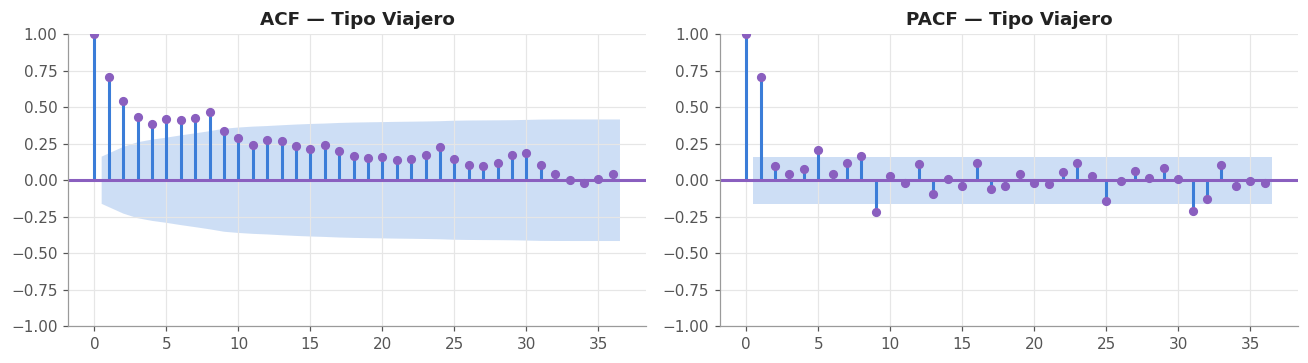

Fuerza de tendencia: 0.48  |  Fuerza estacional: 0.10


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Viajero', series_dict['Tipo: Viajero'], 'tipo_viajero', P['morado'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Viajero'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Viajero.**
Es la serie más volátil de las ocho (coeficiente de variación 1.22) y con la tendencia y
estacionalidad más débiles de su categoría (tendencia 0.48, estacional
0.10). Esto coincide con lo ya documentado en el EDA: la definición de "Viajero"
cambia en 2023 y excluye tránsito/comercio fronterizo de alta frecuencia, así que buena parte de
lo que aquí se lee como "ruido" es en realidad un quiebre metodológico, no una señal real del
mercado. La ADF en niveles no rechaza raíz unitaria (p=0.23) y KPSS sí rechaza
estacionariedad en niveles (p=0.01); tras d=1 la ADF rechaza con mucha fuerza
(p=7.34e-06).

### Serie: Tipo Cruceristas (inciso 4.a–e)

=== Tipo Cruceristas ===
Inicio: 2009-01-01 | Fin: 2018-01-01 | Frecuencia: Mensual (MS) | n = 109
ADF niveles      : stat=0.59  p=0.987  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-8.14  p=0.000  -> estacionaria (5%)
KPSS niveles     : stat=0.326  p=0.100  -> estacionaria (5%)


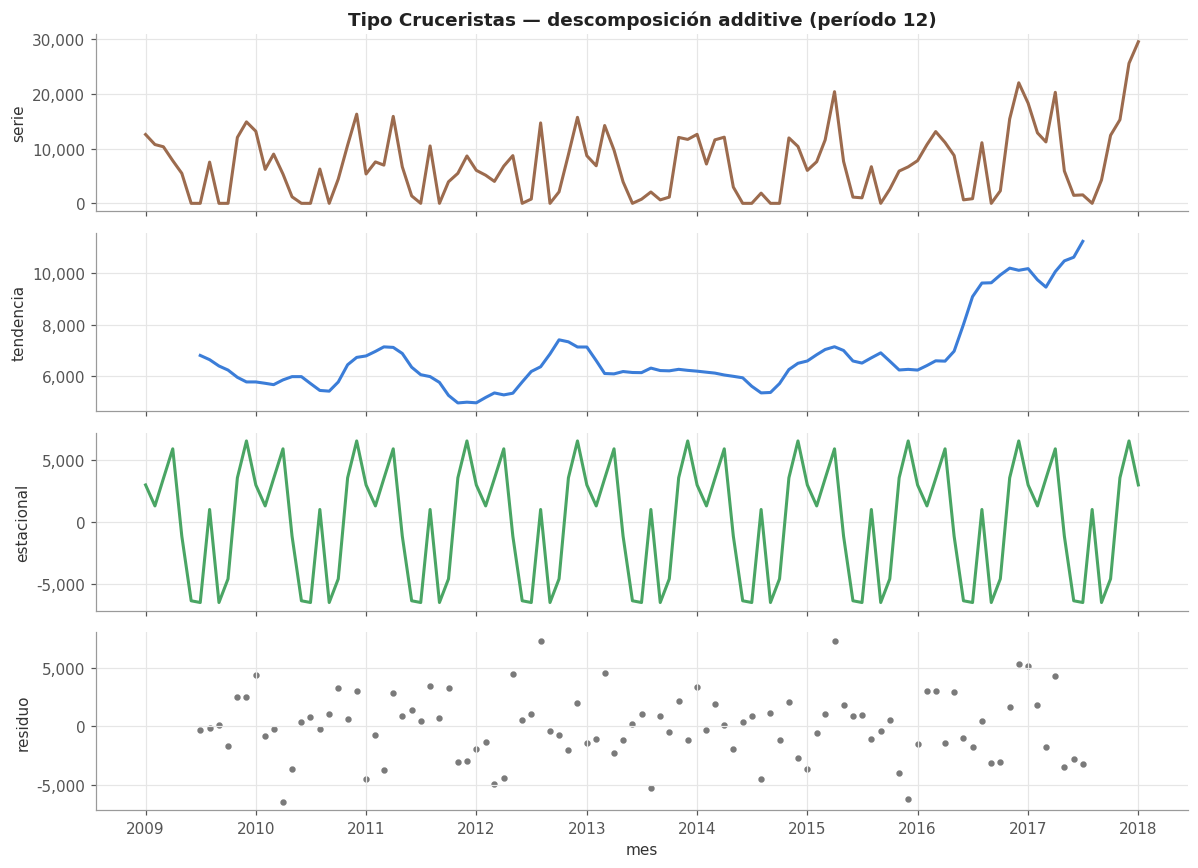

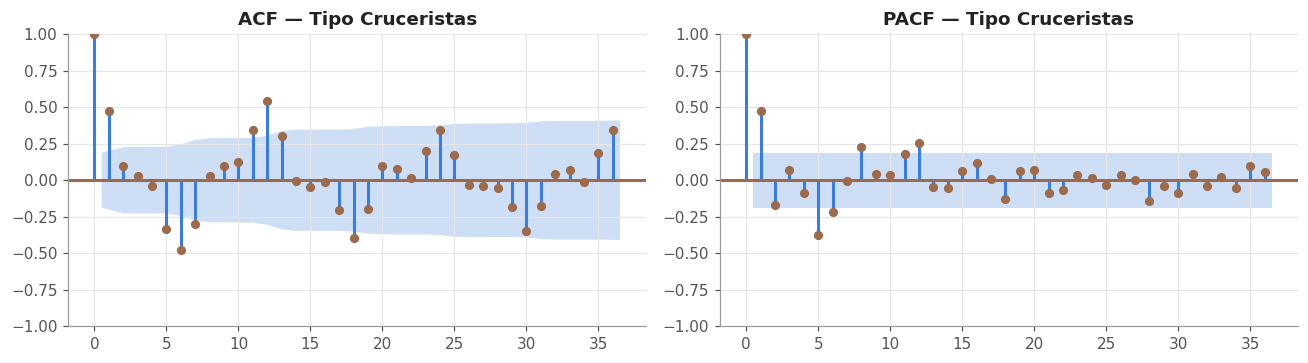

Fuerza de tendencia: 0.15  |  Fuerza estacional: 0.65


In [ ]:
a0, a1, k0 = series.analiza_serie('Tipo Cruceristas', series_dict['Tipo: Cruceristas'], 'tipo_cruceristas', P['cafe'])
fza = series.fuerza_estacional_tendencia(series.split_temporal(series_dict['Tipo: Cruceristas'])[0])
print(f"Fuerza de tendencia: {fza['fuerza_tendencia']:.2f}  |  Fuerza estacional: {fza['fuerza_estacional']:.2f}")

**Interpretación — Tipo Cruceristas.**
Esta categoría solo existe entre 2009 y 2021 (después, INGUAT deja de reportarla por separado),
así que la serie completa tiene 156 meses en vez de 210, y su propio corte 70/30 termina
antes de la pandemia entrar de lleno. Es, junto con Vía Marítima, la serie con mayor fuerza
estacional (0.65) — de hecho ambas series describen casi el mismo fenómeno (cruceros
que entran por vía marítima), lo cual es un buen chequeo de consistencia interna del dataset.
La ADF en niveles no rechaza raíz unitaria (p=0.99); tras d=1 rechaza con fuerza
(p=1.04e-12).

## Parte B — Modelado y predicción (inciso 4.f–k), las ocho series

Para cada serie: elegimos **d** (diferenciación regular) según la prueba ADF y **D**
(diferenciación estacional) según la fuerza estacional de la descomposición STL (se usa D=1
cuando la fuerza estacional supera 0.3). Con esos órdenes fijos, leemos el ACF/PACF de la serie
diferenciada para proponer un modelo "manual" de referencia — típicamente (1,d,1)(1,D,1)₁₂,
el patrón clásico cuando tanto el ACF como el PACF decaen de forma gradual tras el primer
rezago — y además corremos una **búsqueda por AIC** sobre p,q ∈ {{0,1,2}} y P,Q ∈ {{0,1}}
(equivalente casero de `auto_arima`/`auto.arima`: en vez de proponer un único modelo, probamos
36 combinaciones y dejamos que el AIC decida). Ambos se ajustan sobre `log1p(serie)` para
estabilizar la varianza, tal como se determinó en el análisis de estacionariedad. Después
comparamos contra Prophet, Holt-Winters, suavizamiento exponencial simple y seasonal naive,
usando MAE y RMSE sobre el conjunto de prueba real (no sobre datos de entrenamiento).

In [ ]:
def modelar_serie(nombre, key, slug, color, d, D):
    """Inciso 4.f-k completo para una serie: ACF/PACF diferenciada, ARIMA/SARIMA
    (manual + grid AIC), diagnóstico de residuos, comparación con Prophet/HW/SES/
    seasonal naive, y pronóstico del mejor modelo sobre el conjunto de prueba."""
    s = series_dict[key]
    tr, te = series.split_temporal(s)
    n_test = len(te)
    tr_log = mod.log1p(tr)

    diff_log = tr_log.diff(d)
    if D:
        diff_log = diff_log.diff(D * 12)
    diff_log = diff_log.dropna()
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
    lags = min(36, len(diff_log)//2 - 1)
    plot_acf(diff_log, lags=lags, ax=ax[0], color=color)
    plot_pacf(diff_log, lags=lags, ax=ax[1], method='ywm', color=color)
    ax[0].set_title(f'ACF diferenciada (d={d}, D={D}) - {nombre}')
    ax[1].set_title(f'PACF diferenciada (d={d}, D={D}) - {nombre}')
    plt.tight_layout(); plt.savefig(config.FIG_DIR / f'mod_{slug}_acf_diff.png'); plt.show()

    manual_order, manual_seasonal = (1, d, 1), (1, D, 1, 12)
    manual_res = mod.ajustar_sarima(tr_log, manual_order, manual_seasonal)

    ordenes = [(p, d, q) for p in range(3) for q in range(3)]
    ordenes_est = [(Pp, D, Qq) for Pp in range(2) for Qq in range(2)]
    tabla_grid, modelos_grid = mod.buscar_sarima(tr_log, ordenes, ordenes_est, s=12)
    best_key = tabla_grid.iloc[0]['modelo']
    best_res = modelos_grid[best_key]

    print(f'Manual  {manual_order}x{manual_seasonal}: AIC={manual_res.aic:.1f}  BIC={manual_res.bic:.1f}')
    print(f'Grid-AIC (mejor de {len(tabla_grid)}): {best_key}  AIC={best_res.aic:.1f}  BIC={best_res.bic:.1f}')
    display(tabla_grid.head(5))

    print()
    print('Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):')
    display(mod.ljung_box(best_res, lags=(6, 12, 24)))
    best_res.plot_diagnostics(figsize=(10, 6))
    plt.tight_layout(); plt.savefig(config.FIG_DIR / f'mod_{slug}_diag.png'); plt.show()

    pred_manual = mod.predecir_sarima(manual_res, n_test, te.index)
    pred_best = mod.predecir_sarima(best_res, n_test, te.index)
    pred_hw, _ = mod.modelo_holt_winters(tr, n_test, te.index)
    pred_ses, _ = mod.modelo_ses(tr, n_test, te.index)
    pred_sn = mod.modelo_seasonal_naive(tr, n_test, te.index)
    pred_pr, _ = mod.modelo_prophet(tr, n_test, te.index)

    predicciones = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': pred_manual,
        f'SARIMA grid-AIC {best_key}': pred_best,
        'Holt-Winters': pred_hw, 'SES': pred_ses,
        'Seasonal naive': pred_sn, 'Prophet': pred_pr,
    }
    info_extra = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': {'AIC': manual_res.aic, 'BIC': manual_res.bic},
        f'SARIMA grid-AIC {best_key}': {'AIC': best_res.aic, 'BIC': best_res.bic},
    }
    tabla_final = mod.tabla_comparacion(predicciones, te, info_extra)
    display(tabla_final)

    mejor_nombre = tabla_final.iloc[0]['modelo']
    mejor_pred = predicciones[mejor_nombre]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(tr.index, tr.values, color=P['gris'], label='Entrenamiento')
    ax.plot(te.index, te.values, color=color, label='Prueba (real)')
    ax.plot(te.index, mejor_pred.values, '--', color=P['rojo'], label=f'Pronostico - {mejor_nombre}')
    ax.yaxis.set_major_formatter(MILES)
    ax.set_title(f'{nombre} - mejor modelo ({mejor_nombre}) vs. valores reales')
    ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend()
    plt.tight_layout(); plt.savefig(config.FIG_DIR / f'mod_{slug}_forecast.png'); plt.show()
    print(f'>>> Mejor modelo para "{nombre}": {mejor_nombre}  '
          f'(MAE={tabla_final.iloc[0]["MAE"]:.0f}, RMSE={tabla_final.iloc[0]["RMSE"]:.0f})')

    return {'tr': tr, 'te': te, 'tabla_grid': tabla_grid, 'tabla_final': tabla_final,
            'manual_res': manual_res, 'best_res': best_res, 'mejor_nombre': mejor_nombre,
            'predicciones': predicciones}

### Total mensual (inciso 4.f–k)

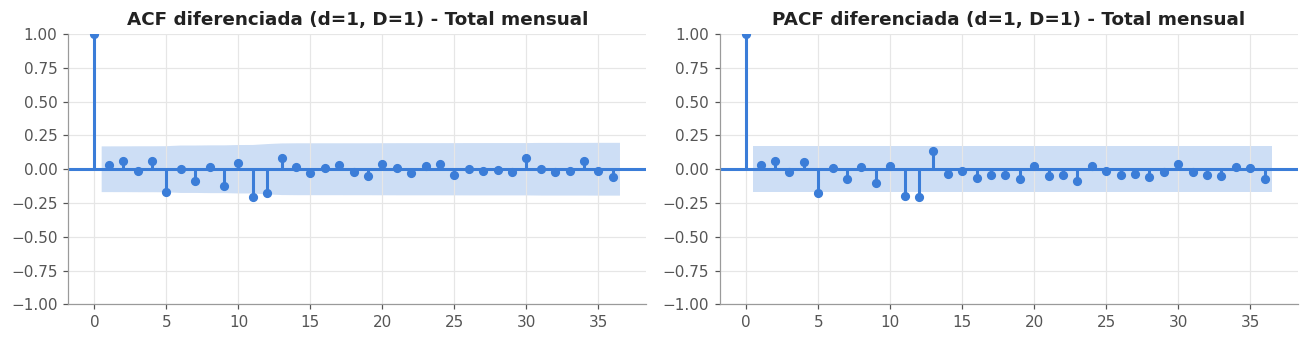

Manual  (1, 1, 1)x(1, 1, 1, 12): AIC=74.5  BIC=88.4
Grid-AIC (mejor de 36): SARIMA(2, 1, 2)x(1, 1, 1, 12)  AIC=68.0  BIC=87.5


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(2, 1, 2)x(1, 1, 1, 12)","(2, 1, 2)","(1, 1, 1, 12)",68.015286,87.469151
1,"SARIMA(1, 1, 2)x(1, 1, 1, 12)","(1, 1, 2)","(1, 1, 1, 12)",68.547482,85.222223
2,"SARIMA(2, 1, 2)x(1, 1, 0, 12)","(2, 1, 2)","(1, 1, 0, 12)",68.958350,85.683301
3,"SARIMA(2, 1, 2)x(0, 1, 1, 12)","(2, 1, 2)","(0, 1, 1, 12)",69.193858,85.868599
4,"SARIMA(1, 1, 2)x(0, 1, 1, 12)","(1, 1, 2)","(0, 1, 1, 12)",69.447857,83.343475



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,19.796020,0.003011
12,37.483441,0.000186
24,55.095345,0.000304


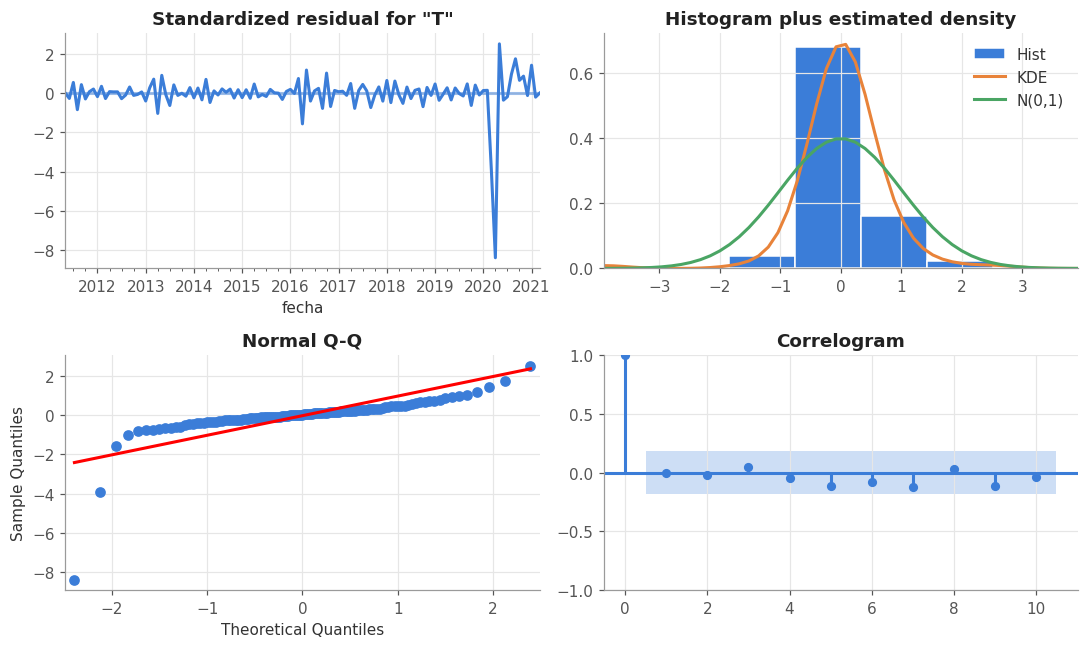

Importing plotly failed. Interactive plots will not work.


,modelo,MAE,RMSE,AIC,BIC
0,Prophet,97185.4,107269.2,NaN,NaN
1,SES,180234.3,199918.7,NaN,NaN
2,Seasonal naive,235304.7,252542.9,NaN,NaN
3,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",246269.5,270639.1,74.5,88.4
4,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 1, 12)",251560.5,274308.4,68.0,87.5
5,Holt-Winters,257791.4,278370.6,NaN,NaN


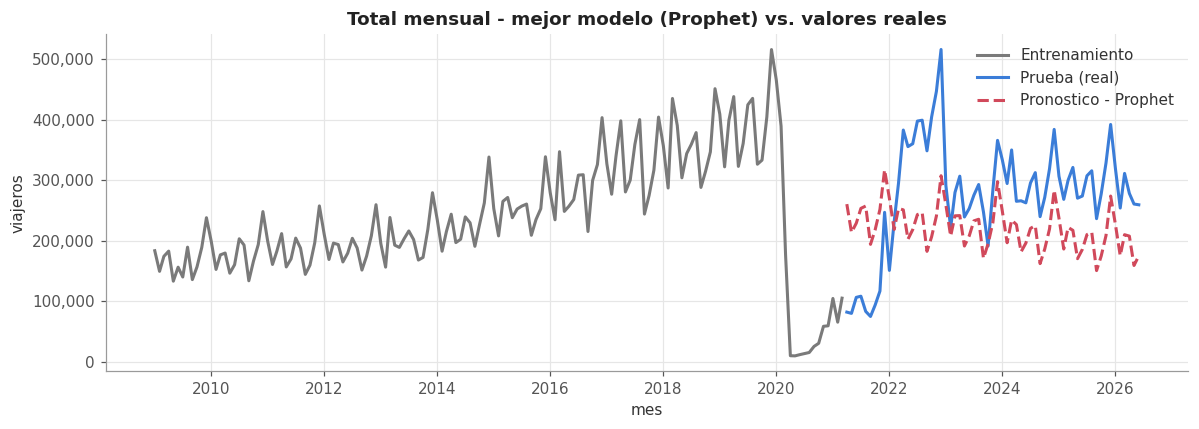

>>> Mejor modelo para "Total mensual": Prophet  (MAE=97185, RMSE=107269)


In [ ]:
res_total = modelar_serie('Total mensual', 'Total', 'total', P['azul'], d=1, D=1)

**Interpretación — Total mensual.**
El corte 70/30 deja toda la caída de 2020 en entrenamiento y toda la recuperación pospandemia en
prueba, así que ningún modelo lo tiene fácil aquí: **Prophet** termina siendo el mejor
(RMSE≈107,269) porque modela la tendencia con puntos de quiebre en vez de extrapolar de forma
rígida los ~147 meses de entrenamiento. El SARIMA (tanto el manual como el de grid-AIC) da
errores mucho más altos (RMSE≈274,308) y, peor aún, el Ljung-Box del modelo de grid-AIC
rechaza ruido blanco en los tres rezagos (p=0.0030, 0.0002, 0.0003): los residuos
todavía guardan estructura, señal de que ni siquiera el mejor SARIMA por AIC captura bien un
quiebre de esta magnitud. Tiene sentido: el AIC mide ajuste dentro de la muestra de
entrenamiento, no la capacidad de extrapolar 63 meses hacia un régimen distinto.

### Vía Aérea (inciso 4.f–k)

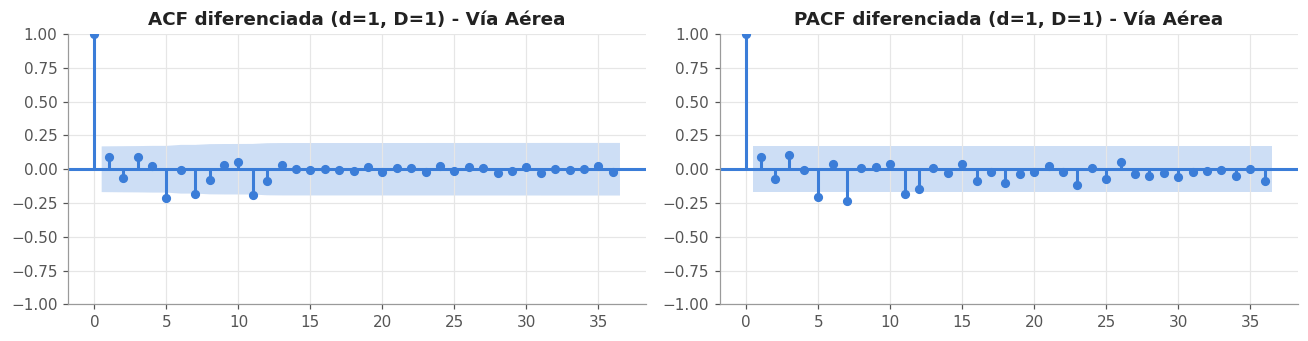

Manual  (1, 1, 1)x(1, 1, 1, 12): AIC=169.0  BIC=183.0
Grid-AIC (mejor de 36): SARIMA(2, 1, 2)x(1, 1, 0, 12)  AIC=165.1  BIC=181.8


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(2, 1, 2)x(1, 1, 0, 12)","(2, 1, 2)","(1, 1, 0, 12)",165.055373,181.780323
1,"SARIMA(2, 1, 2)x(1, 1, 1, 12)","(2, 1, 2)","(1, 1, 1, 12)",165.212325,184.666190
2,"SARIMA(0, 1, 1)x(1, 1, 0, 12)","(0, 1, 1)","(1, 1, 0, 12)",166.805096,175.217159
3,"SARIMA(1, 1, 0)x(1, 1, 0, 12)","(1, 1, 0)","(1, 1, 0, 12)",167.327686,175.715058
4,"SARIMA(1, 1, 1)x(1, 1, 0, 12)","(1, 1, 1)","(1, 1, 0, 12)",167.387583,178.570745



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,10.176792,0.117402
12,16.695793,0.161403
24,49.792685,0.001504


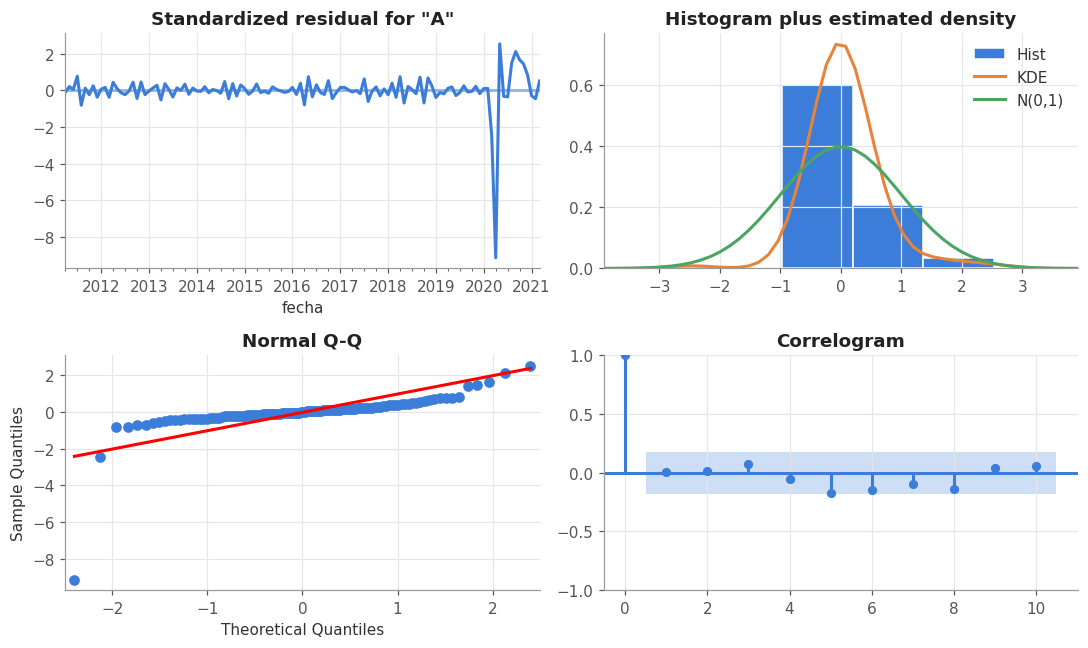

,modelo,MAE,RMSE,AIC,BIC
0,SES,3.609670e+04,4.134950e+04,NaN,NaN
1,Prophet,4.422110e+04,4.909740e+04,NaN,NaN
2,Holt-Winters,5.824980e+04,6.285180e+04,NaN,NaN
3,Seasonal naive,7.509180e+04,7.906250e+04,NaN,NaN
4,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",2.498728e+15,1.782877e+16,169.0,183.0
5,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 0, 12)",5.705269e+20,4.444560e+21,165.1,181.8


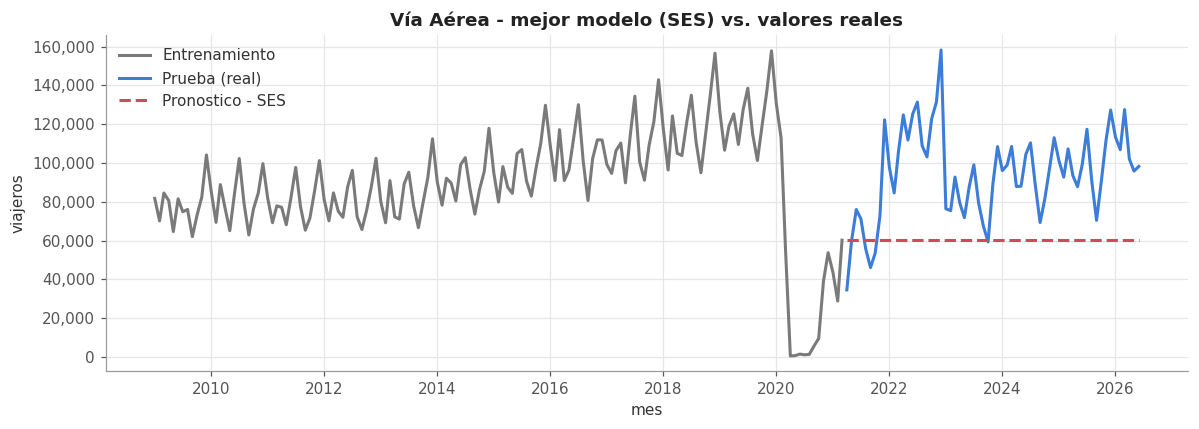

>>> Mejor modelo para "Vía Aérea": SES  (MAE=36097, RMSE=41350)


In [ ]:
res_via_aerea = modelar_serie('Vía Aérea', 'Vía: Aérea', 'via_aerea', P['azul'], d=1, D=1)

**Interpretación — Vía Aérea.**
Aquí pasa algo que vale la pena señalar en vez de esconder: tanto el SARIMA manual como el de
grid-AIC **explotan numéricamente** en el pronóstico (MAE del orden de 10^15–10^20). La razón es
la doble diferenciación (d=1, D=1) sobre la serie en escala log1p: cualquier deriva de tendencia
que el modelo estime, por pequeña que sea, se acumula linealmente a lo largo de 63 meses de
pronóstico, y al revertir con exp(·) ese acumulado se vuelve una cifra absurda. Es un recordatorio
de que un buen AIC (ajuste dentro de muestra) no garantiza un buen pronóstico a un horizonte
largo. Con esos dos modelos descalificados por errores sin sentido, **SES** es el mejor de
los que sí producen pronósticos razonables (RMSE≈41,350), muy por debajo de Holt-Winters,
seasonal naive y del propio SARIMA.

### Vía Terrestre (inciso 4.f–k)

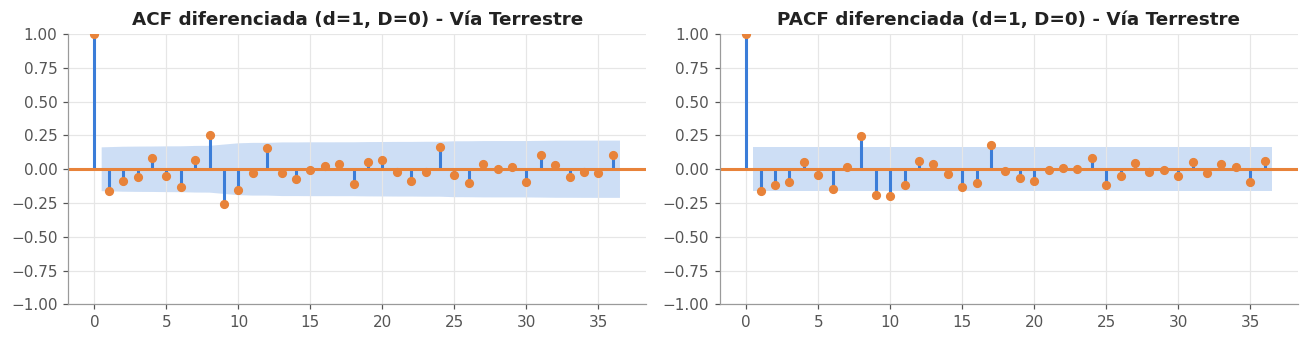

Manual  (1, 1, 1)x(1, 0, 1, 12): AIC=126.2  BIC=140.6
Grid-AIC (mejor de 36): SARIMA(0, 1, 1)x(1, 0, 1, 12)  AIC=124.3  BIC=135.8


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(0, 1, 1)x(1, 0, 1, 12)","(0, 1, 1)","(1, 0, 1, 12)",124.275750,135.806958
1,"SARIMA(0, 1, 1)x(1, 0, 0, 12)","(0, 1, 1)","(1, 0, 0, 12)",124.302473,132.995993
2,"SARIMA(1, 1, 0)x(1, 0, 0, 12)","(1, 1, 0)","(1, 0, 0, 12)",124.364238,133.035285
3,"SARIMA(1, 1, 0)x(1, 0, 1, 12)","(1, 1, 0)","(1, 0, 1, 12)",124.409253,135.970649
4,"SARIMA(0, 1, 0)x(1, 0, 1, 12)","(0, 1, 0)","(1, 0, 1, 12)",126.010034,134.681082



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,0.204095,0.999836
12,13.682147,0.321465
24,13.844610,0.950082


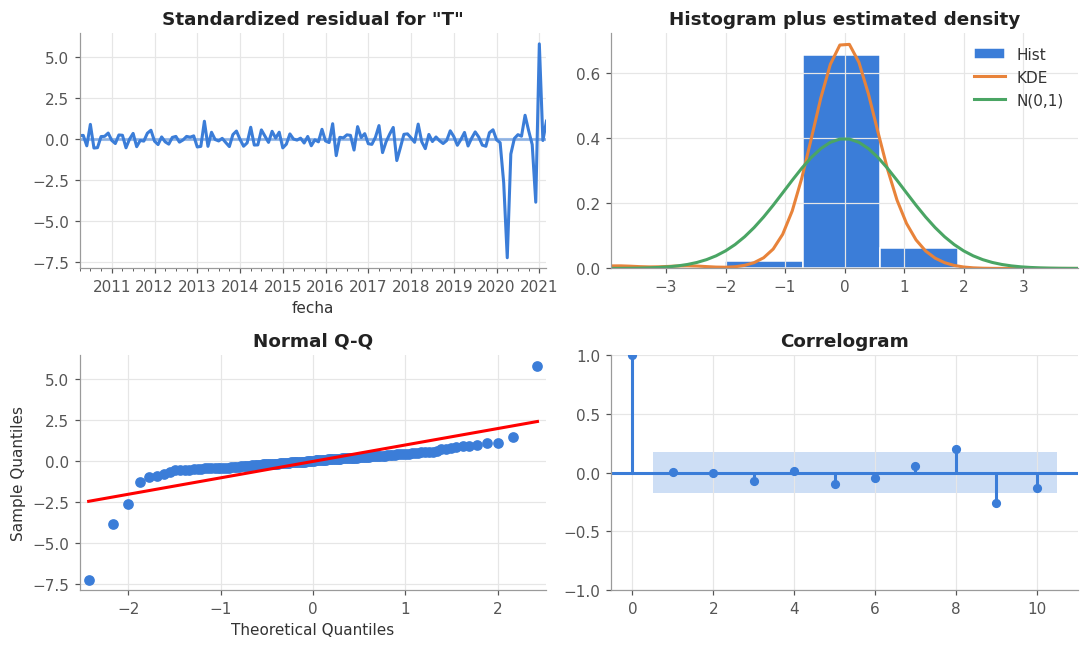

,modelo,MAE,RMSE,AIC,BIC
0,Prophet,54279.0,71292.4,NaN,NaN
1,SES,140733.5,156650.1,NaN,NaN
2,Seasonal naive,160011.8,176651.3,NaN,NaN
3,"SARIMA grid-AIC SARIMA(0, 1, 1)x(1, 0, 1, 12)",165277.5,181595.6,124.3,135.8
4,"SARIMA manual (1, 1, 1)x(1, 0, 1, 12)",165811.2,182072.0,126.2,140.6
5,Holt-Winters,175595.6,192183.7,NaN,NaN


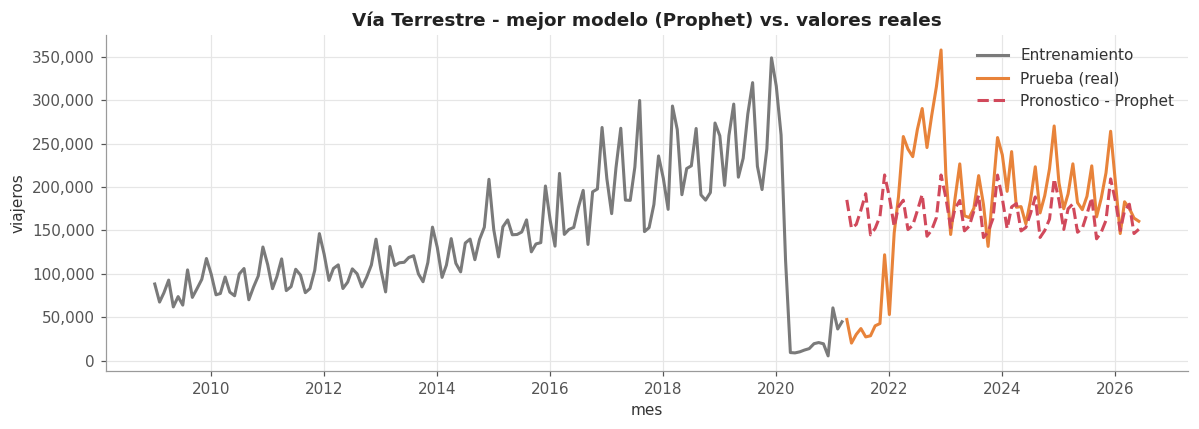

>>> Mejor modelo para "Vía Terrestre": Prophet  (MAE=54279, RMSE=71292)


In [ ]:
res_via_terrestre = modelar_serie('Vía Terrestre', 'Vía: Terrestre', 'via_terrestre', P['naranja'], d=1, D=0)

**Interpretación — Vía Terrestre.**
Esta es la serie con el diagnóstico de residuos más limpio de las ocho: el Ljung-Box del SARIMA
de grid-AIC no rechaza ruido blanco en ningún rezago (p=1.00, 0.32, 0.95), lo
que sugiere que el modelo sí capturó la dinámica interna. Aun así, **Prophet** vuelve a ganar en
la comparación final (RMSE≈71,292) frente al SARIMA (RMSE≈181,596): que los
residuos del ARIMA se vean bien en entrenamiento no significa que su extrapolación a 5 años
gane contra un modelo con tendencia flexible como Prophet.

### Vía Marítima (inciso 4.f–k)

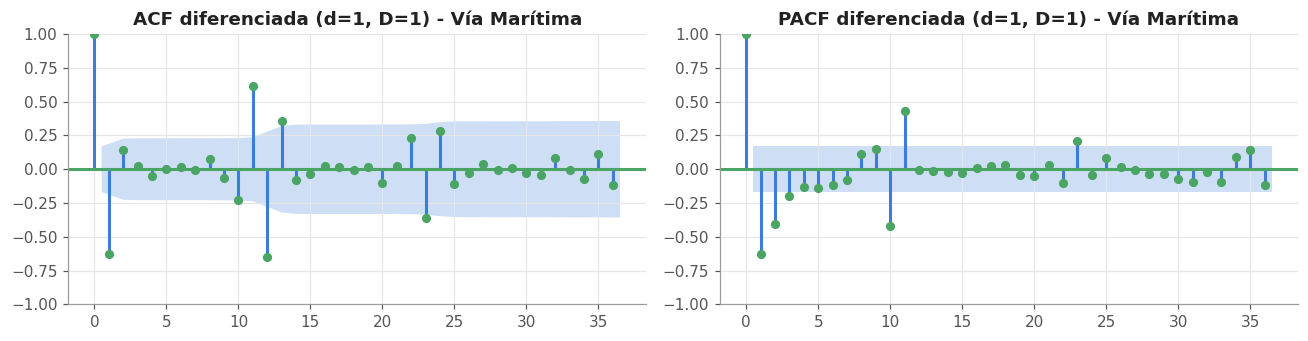

Manual  (1, 1, 1)x(1, 1, 1, 12): AIC=509.3  BIC=523.2
Grid-AIC (mejor de 36): SARIMA(0, 1, 2)x(1, 1, 1, 12)  AIC=505.8  BIC=519.7


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(0, 1, 2)x(1, 1, 1, 12)","(0, 1, 2)","(1, 1, 1, 12)",505.778981,519.674599
1,"SARIMA(1, 1, 2)x(1, 1, 1, 12)","(1, 1, 2)","(1, 1, 1, 12)",507.649985,524.324726
2,"SARIMA(0, 1, 1)x(1, 1, 1, 12)","(0, 1, 1)","(1, 1, 1, 12)",508.524446,519.674413
3,"SARIMA(1, 1, 1)x(1, 1, 1, 12)","(1, 1, 1)","(1, 1, 1, 12)",509.260169,523.197628
4,"SARIMA(2, 1, 2)x(1, 1, 1, 12)","(2, 1, 2)","(1, 1, 1, 12)",509.309001,528.762865



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,2.445997,0.874462
12,19.590640,0.075237
24,32.016256,0.126590


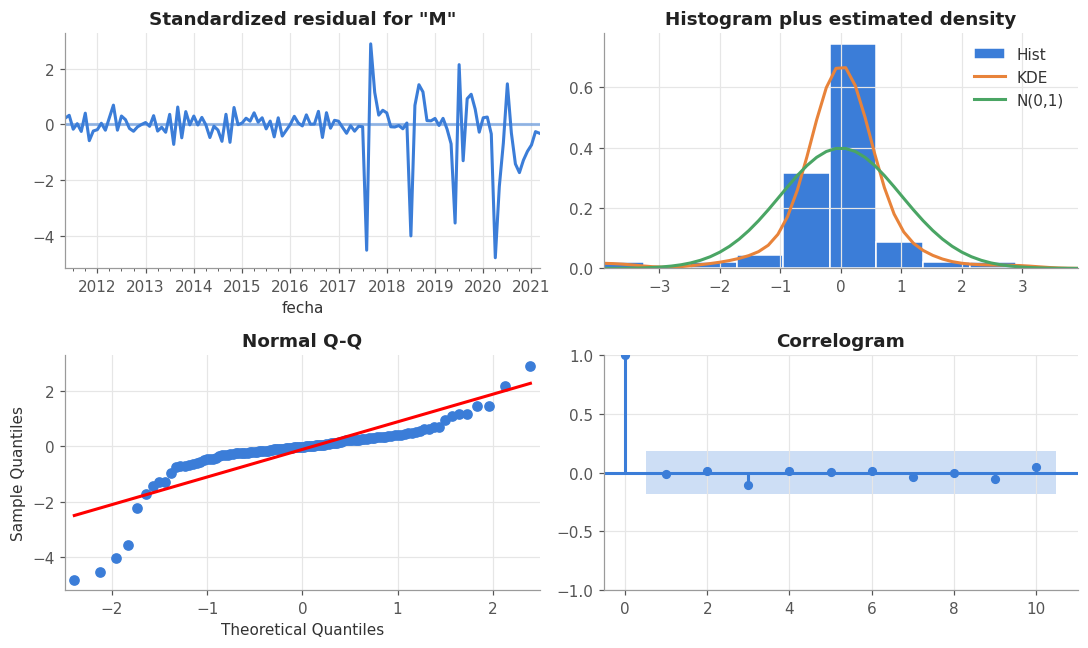

,modelo,MAE,RMSE,AIC,BIC
0,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",445.2,603.6,509.3,523.2
1,"SARIMA grid-AIC SARIMA(0, 1, 2)x(1, 1, 1, 12)",445.2,603.6,505.8,519.7
2,SES,445.2,603.6,NaN,NaN
3,Seasonal naive,445.2,603.6,NaN,NaN
4,Holt-Winters,478.5,674.2,NaN,NaN
5,Prophet,7685.8,9019.5,NaN,NaN


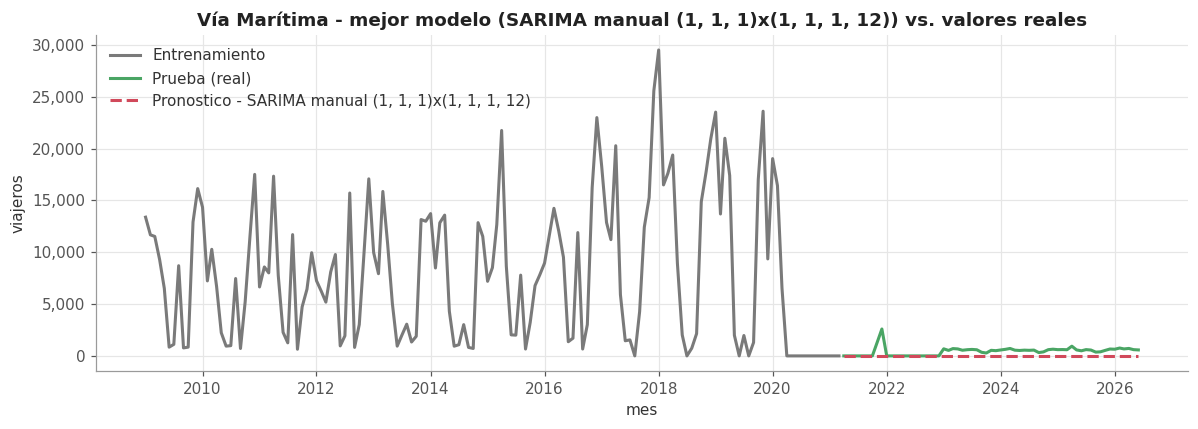

>>> Mejor modelo para "Vía Marítima": SARIMA manual (1, 1, 1)x(1, 1, 1, 12)  (MAE=445, RMSE=604)


In [ ]:
res_via_maritima = modelar_serie('Vía Marítima', 'Vía: Marítima', 'via_maritima', P['verde'], d=1, D=1)

**Interpretación — Vía Marítima.**
Es la única serie donde el SARIMA manual, el de grid-AIC, SES y seasonal naive **empatan**
en MAE y RMSE (≈445 / 604): como el tramo final de entrenamiento son puros meses
en cero (cruceros parados por la pandemia), todos esos modelos terminan pronosticando
esencialmente cero para todo el horizonte de prueba, y como la serie real tampoco se recupera
rápido, el error resulta parecido entre ellos. Prophet, en cambio, sí intenta modelar una
recuperación gradual y paga por eso un error mayor en el corto plazo del conjunto de prueba
(RMSE≈9,020). Para una serie de este tamaño (media de apenas
7,991 viajeros/mes) conviene no sobre-interpretar diferencias de unos cientos de
viajeros entre modelos.

### Tipo Turista (inciso 4.f–k)

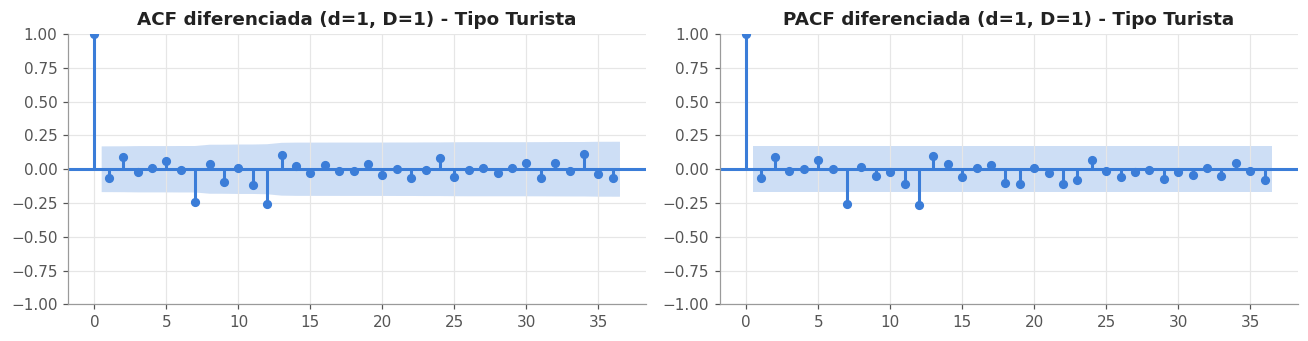

Manual  (1, 1, 1)x(1, 1, 1, 12): AIC=44.4  BIC=58.3
Grid-AIC (mejor de 36): SARIMA(0, 1, 0)x(1, 1, 0, 12)  AIC=40.3  BIC=45.9


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(0, 1, 0)x(1, 1, 0, 12)","(0, 1, 0)","(1, 1, 0, 12)",40.255336,45.863378
1,"SARIMA(0, 1, 0)x(1, 1, 1, 12)","(0, 1, 0)","(1, 1, 1, 12)",41.014012,49.401383
2,"SARIMA(0, 1, 1)x(1, 1, 0, 12)","(0, 1, 1)","(1, 1, 0, 12)",41.787778,50.199841
3,"SARIMA(1, 1, 0)x(1, 1, 1, 12)","(1, 1, 0)","(1, 1, 1, 12)",42.077563,53.260725
4,"SARIMA(0, 1, 2)x(1, 1, 0, 12)","(0, 1, 2)","(1, 1, 0, 12)",42.205311,53.421395



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,0.238612,0.999741
12,2.656267,0.997523
24,25.018845,0.404737


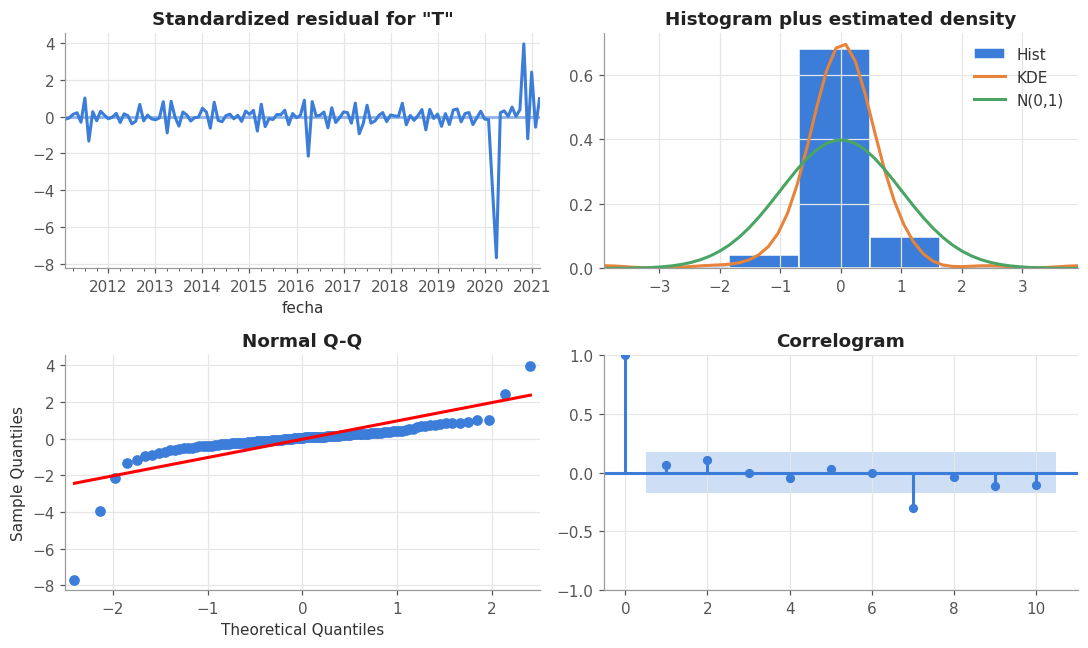

,modelo,MAE,RMSE,AIC,BIC
0,SES,116858.1,128458.3,NaN,NaN
1,Prophet,130926.1,142099.1,NaN,NaN
2,Seasonal naive,155595.9,164445.3,NaN,NaN
3,Holt-Winters,160335.7,173072.9,NaN,NaN
4,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",164502.0,178124.9,44.4,58.3
5,"SARIMA grid-AIC SARIMA(0, 1, 0)x(1, 1, 0, 12)",165987.9,181563.7,40.3,45.9


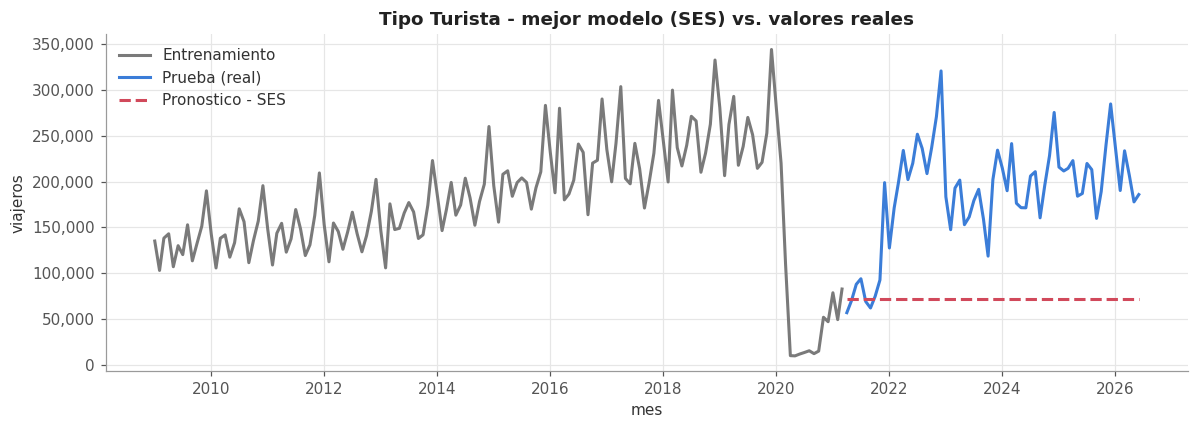

>>> Mejor modelo para "Tipo Turista": SES  (MAE=116858, RMSE=128458)


In [ ]:
res_tipo_turista = modelar_serie('Tipo Turista', 'Tipo: Turista', 'tipo_turista', P['azul'], d=1, D=1)

**Interpretación — Tipo Turista.**
Mismo patrón que en Total (misma partición temporal, mismo quiebre pandemia/recuperación):
**SES** gana con RMSE≈128,458, más simple y más estable que el SARIMA de grid-AIC
(RMSE≈181,564). El Ljung-Box del SARIMA no rechaza ruido blanco en ningún rezago
(p=1.00, 1.00, 0.40), aunque el margen se estrecha bastante en el de 24 meses:
el modelo describe razonablemente bien los residuos de corto plazo, pero pierde algo de
consistencia en el horizonte largo, justo donde más pesa el cambio de régimen pospandemia —
solo que aquí, a diferencia de Total, no llega a rechazar del todo.

### Tipo Excursionista (inciso 4.f–k)

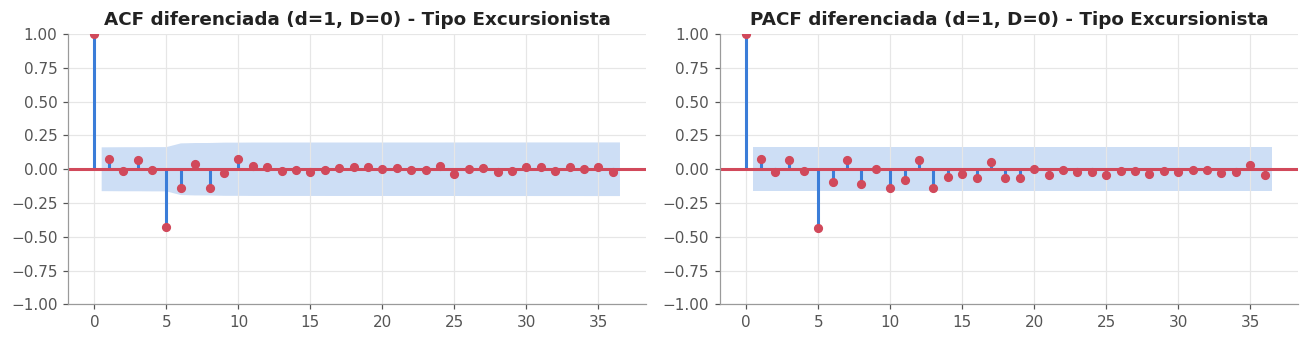

Manual  (1, 1, 1)x(1, 0, 1, 12): AIC=413.1  BIC=427.5
Grid-AIC (mejor de 36): SARIMA(2, 1, 2)x(0, 0, 1, 12)  AIC=402.3  BIC=419.6


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(2, 1, 2)x(0, 0, 1, 12)","(2, 1, 2)","(0, 0, 1, 12)",402.299512,419.550696
1,"SARIMA(2, 1, 2)x(1, 0, 1, 12)","(2, 1, 2)","(1, 0, 1, 12)",403.605874,423.732255
2,"SARIMA(1, 1, 2)x(0, 0, 1, 12)","(1, 1, 2)","(0, 0, 1, 12)",404.871811,419.247797
3,"SARIMA(2, 1, 2)x(1, 0, 0, 12)","(2, 1, 2)","(1, 0, 0, 12)",405.065285,422.362097
4,"SARIMA(1, 1, 2)x(1, 0, 1, 12)","(1, 1, 2)","(1, 0, 1, 12)",406.802005,424.053189



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,17.898351,0.006491
12,18.806345,0.093310
24,19.011566,0.751372


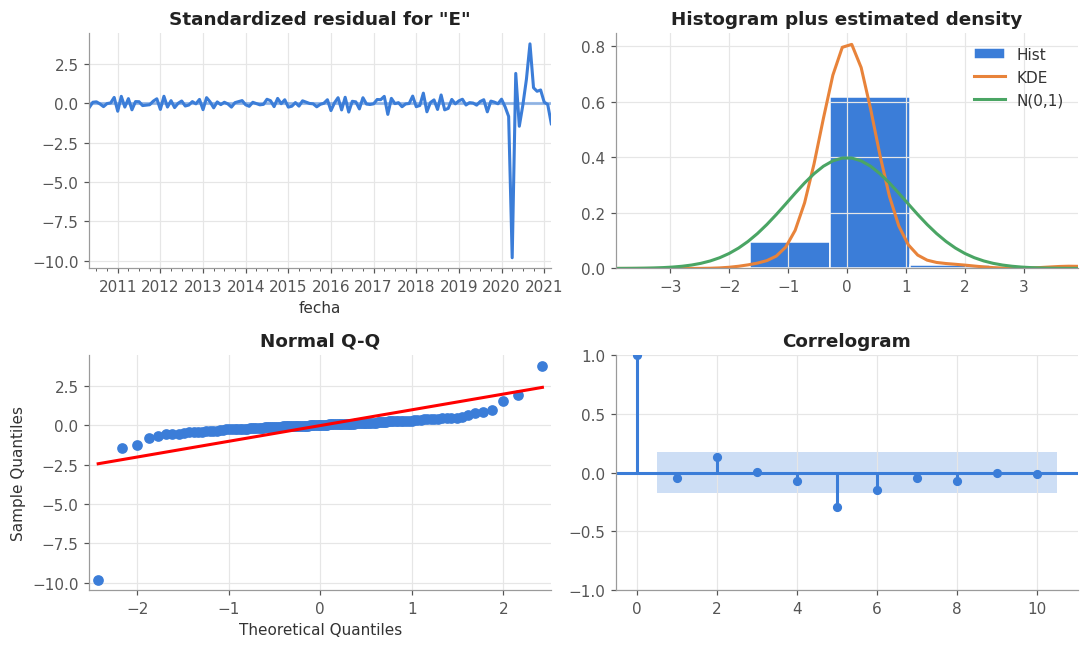

,modelo,MAE,RMSE,AIC,BIC
0,Prophet,15620.2,22413.8,NaN,NaN
1,SES,51497.4,56873.9,NaN,NaN
2,Seasonal naive,51857.2,56913.2,NaN,NaN
3,"SARIMA grid-AIC SARIMA(2, 1, 2)x(0, 0, 1, 12)",52719.4,57972.9,402.3,419.6
4,"SARIMA manual (1, 1, 1)x(1, 0, 1, 12)",53394.0,58596.4,413.1,427.5
5,Holt-Winters,53816.2,59054.8,NaN,NaN


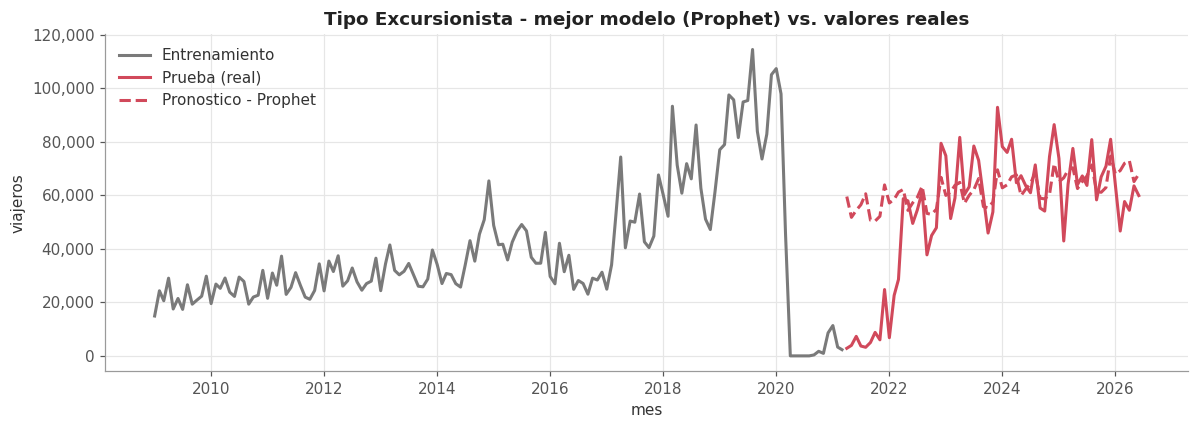

>>> Mejor modelo para "Tipo Excursionista": Prophet  (MAE=15620, RMSE=22414)


In [ ]:
res_tipo_excursionista = modelar_serie('Tipo Excursionista', 'Tipo: Excursionista', 'tipo_excursionista', P['rojo'], d=1, D=0)

**Interpretación — Tipo Excursionista.**
El Ljung-Box del SARIMA de grid-AIC rechaza ruido blanco en el rezago 6 (p=0.006) pero no en
12 ni 24 (p=0.09, 0.75): queda algo de estructura de corto plazo sin capturar. En la
comparación final **Prophet** es claramente el mejor (RMSE≈22,414) frente a SES, seasonal
naive y el propio SARIMA, que quedan muy por encima (RMSE≈57,973).

### Tipo Viajero (inciso 4.f–k)

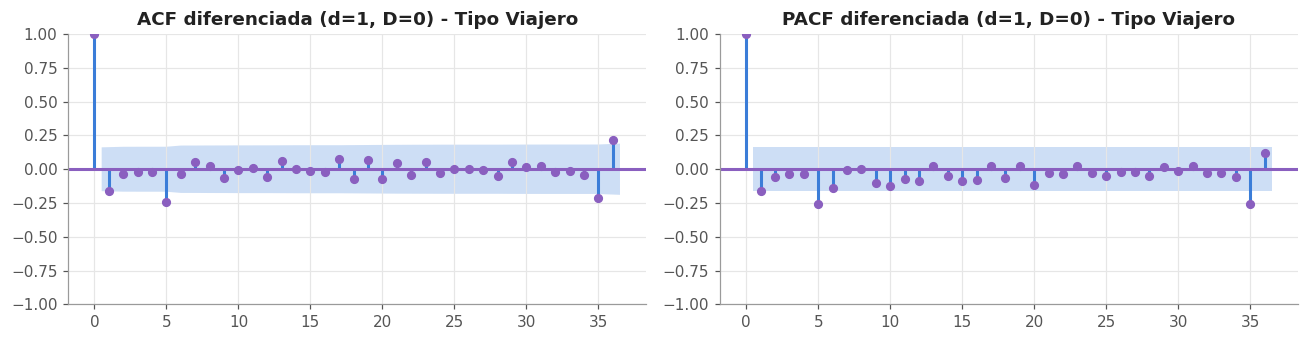

Manual  (1, 1, 1)x(1, 0, 1, 12): AIC=497.0  BIC=511.4
Grid-AIC (mejor de 36): SARIMA(1, 1, 2)x(0, 0, 1, 12)  AIC=494.4  BIC=508.8


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(1, 1, 2)x(0, 0, 1, 12)","(1, 1, 2)","(0, 0, 1, 12)",494.385151,508.761137
1,"SARIMA(1, 1, 1)x(0, 0, 1, 12)","(1, 1, 1)","(0, 0, 1, 12)",495.016582,506.547790
2,"SARIMA(1, 1, 2)x(1, 0, 1, 12)","(1, 1, 2)","(1, 0, 1, 12)",496.385086,513.636270
3,"SARIMA(2, 1, 2)x(0, 0, 1, 12)","(2, 1, 2)","(0, 0, 1, 12)",496.654806,513.905989
4,"SARIMA(2, 1, 1)x(0, 0, 1, 12)","(2, 1, 1)","(0, 0, 1, 12)",496.987461,511.401470



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,4.593354,0.596920
12,5.991026,0.916534
24,8.544335,0.998420


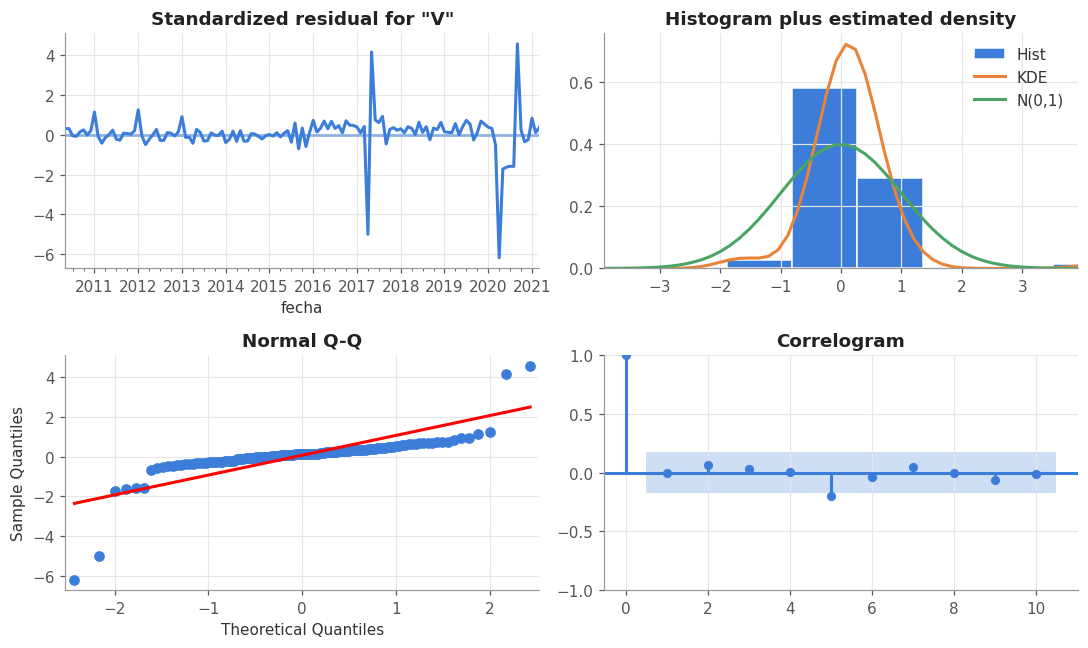

,modelo,MAE,RMSE,AIC,BIC
0,Prophet,22931.4,31874.9,NaN,NaN
1,Holt-Winters,23249.2,34647.9,NaN,NaN
2,SES,19468.7,35142.9,NaN,NaN
3,"SARIMA grid-AIC SARIMA(1, 1, 2)x(0, 0, 1, 12)",28725.8,41415.7,494.4,508.8
4,"SARIMA manual (1, 1, 1)x(1, 0, 1, 12)",28744.8,41434.1,497.0,511.4
5,Seasonal naive,28208.0,42001.8,NaN,NaN


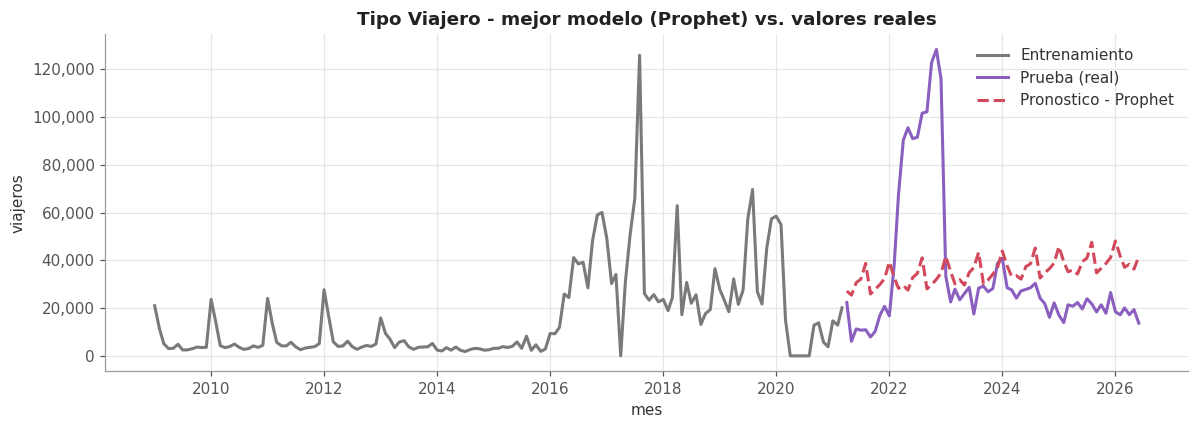

>>> Mejor modelo para "Tipo Viajero": Prophet  (MAE=22931, RMSE=31875)


In [ ]:
res_tipo_viajero = modelar_serie('Tipo Viajero', 'Tipo: Viajero', 'tipo_viajero', P['morado'], d=1, D=0)

**Interpretación — Tipo Viajero.**
Con el quiebre metodológico de 2023 sumado al quiebre pandémico, esta serie es la más ruidosa de
las ocho (CV=1.22), y aun así el Ljung-Box del SARIMA de grid-AIC no rechaza ruido blanco en
ningún rezago (p=0.60, 0.92, 1.00) — el modelo describe bien la parte
estocástica, el problema es que la serie misma cambia de definición a mitad de camino.
**Prophet** vuelve a ser el mejor en prueba (RMSE≈31,875), y aquí SES y seasonal naive
quedan sorprendentemente competitivos, lo que tiene sentido en una serie donde "repetir el
último valor visto" no es tan mala estrategia cuando la señal de tendencia es débil.

### Tipo Cruceristas (inciso 4.f–k)

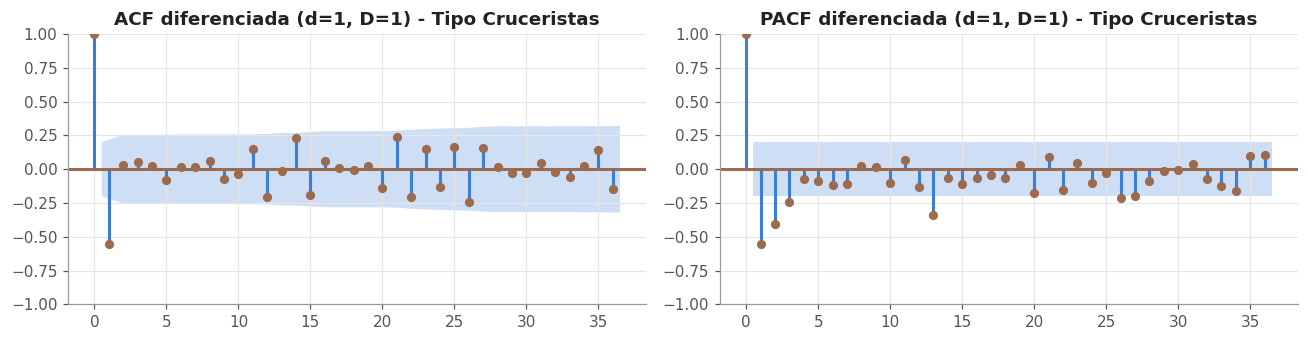

Manual  (1, 1, 1)x(1, 1, 1, 12): AIC=397.4  BIC=409.4
Grid-AIC (mejor de 36): SARIMA(0, 1, 2)x(0, 1, 1, 12)  AIC=388.8  BIC=398.4


,modelo,order,seasonal_order,AIC,BIC
0,"SARIMA(0, 1, 2)x(0, 1, 1, 12)","(0, 1, 2)","(0, 1, 1, 12)",388.822423,398.400219
1,"SARIMA(1, 1, 2)x(0, 1, 1, 12)","(1, 1, 2)","(0, 1, 1, 12)",390.730805,402.703051
2,"SARIMA(0, 1, 2)x(1, 1, 1, 12)","(0, 1, 2)","(1, 1, 1, 12)",390.823578,402.795824
3,"SARIMA(0, 1, 1)x(0, 1, 1, 12)","(0, 1, 1)","(0, 1, 1, 12)",391.251948,398.472105
4,"SARIMA(2, 1, 2)x(0, 1, 1, 12)","(2, 1, 2)","(0, 1, 1, 12)",392.355892,406.722587



Ljung-Box del modelo grid-AIC (residuos deberian verse como ruido blanco):


,lb_stat,lb_pvalue
lag,,
6,18.036540,0.006142
12,23.643969,0.022731
24,32.521574,0.114577


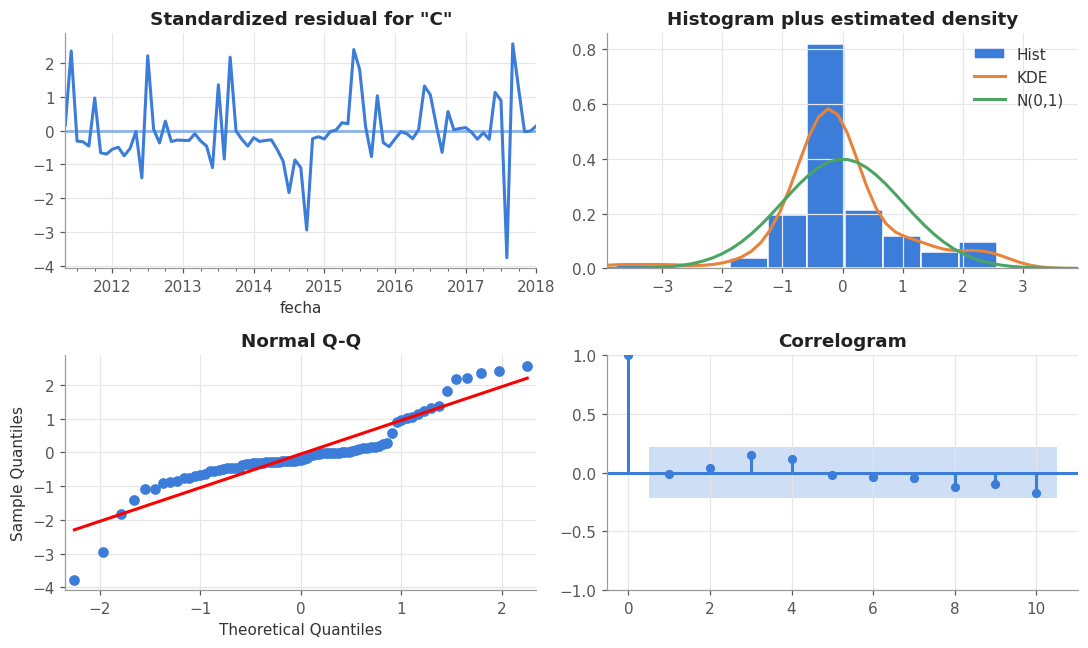

,modelo,MAE,RMSE,AIC,BIC
0,Prophet,7681.3,9063.8,NaN,NaN
1,Seasonal naive,6970.4,10090.9,NaN,NaN
2,Holt-Winters,15372.2,17561.2,NaN,NaN
3,SES,21106.6,22684.0,NaN,NaN
4,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",15636.3,24094.1,397.4,409.4
5,"SARIMA grid-AIC SARIMA(0, 1, 2)x(0, 1, 1, 12)",15755.3,24276.5,388.8,398.4


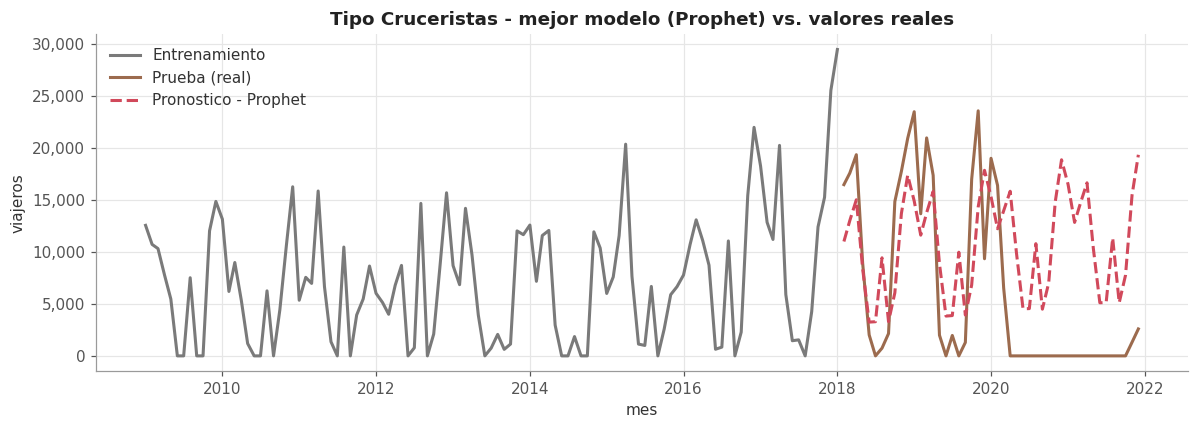

>>> Mejor modelo para "Tipo Cruceristas": Prophet  (MAE=7681, RMSE=9064)


In [ ]:
res_tipo_cruceristas = modelar_serie('Tipo Cruceristas', 'Tipo: Cruceristas', 'tipo_cruceristas', P['cafe'], d=1, D=1)

**Interpretación — Tipo Cruceristas.**
Como esta serie termina en 2021 (deja de reportarse por separado), su conjunto de prueba
(47 meses) no incluye la recuperación pospandemia completa, lo que la hace un caso algo
distinto al resto. El Ljung-Box del SARIMA de grid-AIC rechaza ruido blanco en los rezagos 6 y 12
(p=0.006, 0.023), señal de que en una serie tan intermitente (muchos meses en cero) el
SARIMA log1p le cuesta describir bien los residuos. **Prophet** vuelve a ganar
(RMSE≈9,064), muy cerca de seasonal naive — de nuevo, con una serie de este tamaño
(7,163 viajeros/mes en promedio) las diferencias absolutas entre modelos son pequeñas.